In [3]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Flatten, Input, Activation
from tensorflow.keras.layers import Reshape, Conv2DTranspose
from tensorflow.keras.models import Model
from tensorflow.keras import backend as K

In [4]:
import numpy as np
from pathlib import Path

In [5]:
from dataset import make_sr_dataset
import matplotlib.pyplot as plt

2.20.0


In [7]:
np.random.seed(7)

In [8]:
HR_SIZE = 128
SCALE = 2
LR_SIZE = 64
BATCH = 8
EPOCHS = 10

In [9]:
ROOT = Path("data/raw/Flickr2K")
path = [str(p) for p in ROOT.glob('*.png')]

In [10]:
print(path[:5])

['data/raw/Flickr2K/001927.png', 'data/raw/Flickr2K/001099.png', 'data/raw/Flickr2K/000387.png', 'data/raw/Flickr2K/002590.png', 'data/raw/Flickr2K/002584.png']


In [11]:
np.random.shuffle(path)

In [12]:
train_paths = path[:2120]
val_paths = path[2120:2120+265]
test_paths = path[2120+265 :]

In [13]:
print(len(train_paths))
print(len(val_paths))
print(len(test_paths))

2120
265
265


In [14]:
ds_train = make_sr_dataset(train_paths,HR_SIZE,SCALE,BATCH,True)
ds_val = make_sr_dataset(val_paths,HR_SIZE,SCALE,BATCH,False)

In [15]:
input_shape = (64,64,3)
kernel_size = 3
layer_filters = [32, 64,128]

In [16]:
inputs = Input(shape = input_shape,name= 'encoder_input')
x = inputs

for filters in layer_filters:
    x = Conv2D(filters = filters,kernel_size = kernel_size,strides = 1,activation = 'relu',padding = 'same')(x)
    x = Conv2D(filters = filters,kernel_size = kernel_size,strides = 1,activation = 'relu',padding = 'same')(x)
    x = Conv2D(filters = filters,kernel_size = kernel_size,strides = 2,activation = 'relu',padding = 'same')(x)


shape = K.int_shape(x)

encoder = Model(inputs,x,name = 'encoder')
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 480,768 (1.83 MB)

 Trainable params: 480,768 (1.83 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
decoder_input = Input(shape=(8,8,128))
x = decoder_input
for filters in layer_filters[::-1]:
    x = Conv2DTranspose(filters = filters,kernel_size = kernel_size,strides = 2,activation = 'relu',padding = 'same')(x)
    x = Conv2D(filters = filters,kernel_size = kernel_size,strides = 1,activation = 'relu',padding = 'same')(x)
    x = Conv2D(filters = filters,kernel_size = kernel_size,strides = 1,activation = 'relu',padding = 'same')(x)

x = Conv2DTranspose(filters = 3,kernel_size = kernel_size, strides = 2,padding= 'same')(x)
#x = Conv2D(filters = filters,kernel_size = kernel_size,strides = 1,activation = 'relu',padding = 'same')(x)

outputs = Activation('sigmoid',name = 'decoder_output')(x)
decoder = Model(inputs = decoder_input, outputs = outputs, name = 'decoder')

decoder.summary(line_length = 110)

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                   ┃ Output Shape                        ┃             Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)                       │ (None, 8, 8, 128)                   │                   0 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ conv2d_transpose (Conv2DTranspose)             │ (None, 16, 16, 128)                 │             147,584 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ conv2d_9 (Conv2D)                              │ (None, 16, 16, 128)                 │             147,584 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ conv2d_10 (Conv2D)                             │ (None, 16, 16, 128)                 │             147,584 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ conv2d_transpose_1 (Conv2DTranspose)           │ (None, 32, 32, 64)                  │              73,792 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ conv2d_11 (Conv2D)                             │ (None, 32, 32, 64)                  │              36,928 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ conv2d_12 (Conv2D)                             │ (None, 32, 32, 64)                  │              36,928 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ conv2d_transpose_2 (Conv2DTranspose)           │ (None, 64, 64, 32)                  │              18,464 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ conv2d_13 (Conv2D)                             │ (None, 64, 64, 32)                  │               9,248 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ conv2d_14 (Conv2D)                             │ (None, 64, 64, 32)                  │               9,248 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ conv2d_transpose_3 (Conv2DTranspose)           │ (None, 128, 128, 3)                 │                 867 │
├────────────────────────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│ decoder_output (Activation)                    │ (None, 128, 128, 3)                 │                   0 │
└────────────────────────────────────────────────┴─────────────────────────────────────┴─────────────────────┘

 Total params: 628,227 (2.40 MB)

 Trainable params: 628,227 (2.40 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
autoencoder = Model(inputs,decoder(encoder(inputs)),name = 'autoencoder')
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 8, 8, 128)      │       480,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 128, 128, 3)    │       628,227 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,108,995 (4.23 MB)

 Trainable params: 1,108,995 (4.23 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
import platform
print(platform.platform())
print(platform.processor())

macOS-26.3-arm64-arm-64bit
arm


In [20]:
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print(tf.config.list_physical_devices('GPU'))

Num GPUs Available: 0
[]


In [21]:
def psnr_metrics(y_true,y_pred):
    return tf.image.psnr(y_true,y_pred,max_val = 1.0)

In [22]:
autoencoder.compile(loss='MAE', metrics = [psnr_metrics],optimizer='adam')

In [23]:
history = autoencoder.fit(
    ds_train,
    validation_data=ds_val,
    epochs=20,
    verbose=1
)

In [24]:
print(history.history.keys())

dict_keys(['loss', 'psnr_metrics', 'val_loss', 'val_psnr_metrics'])


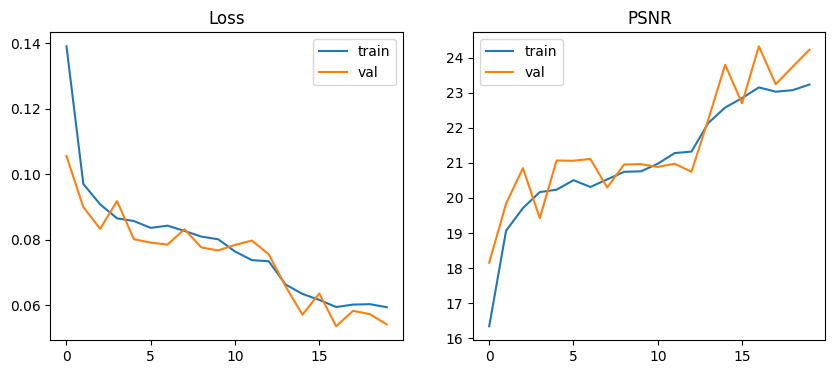

In [25]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['psnr_metrics'], label='train')
plt.plot(history.history['val_psnr_metrics'], label='val')
plt.title("PSNR")
plt.legend()

plt.show()

Epoch 1/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 0.2339 - psnr_metrics: 12.0561
Epoch 2/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.2337 - psnr_metrics: 12.0625
Epoch 3/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.2335 - psnr_metrics: 12.0709
Epoch 4/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.2332 - psnr_metrics: 12.0812
Epoch 5/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.2329 - psnr_metrics: 12.0931
Epoch 6/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.2325 - psnr_metrics: 12.1067
Epoch 7/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.2319 - psnr_metrics: 12.1216
Epoch 8/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.2311 - psnr_metrics: 12.1340
Epoch 9/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.2300 - psnr_metrics: 12.1100
Epoch 10/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.2352 - psnr_metrics: 11.6016
Epoch 11/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.2288 - psnr_metrics: 12.1298
Epoch 12/300
1/1 ━━

pred min: 0.0005804319
pred max: 0.9983047
pred mean: 0.5503153
